# N-HiTS (Darts)
Notebook autocontido para treinar e avaliar um **N-HiTS** na mesma régua dos outros modelos
(SARIMAX, XGBoost, LSTM): split 2013–2017 / 2018 / jan–ago 2019, walk-forward de 24h, métricas
MAE / RMSE / R² / MASE.

In [1]:
import torch
import pytorch_lightning as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from darts import TimeSeries, concatenate
from darts.models import NHiTSModel
from darts.dataprocessing.transformers import Scaler
from darts.metrics import mae, rmse, r2_score, mase
from pytorch_lightning.callbacks import EarlyStopping

print("torch", torch.__version__, "| lightning", pl.__version__)

torch 2.6.0+cpu-cxx11-abi | lightning 2.5.2


In [2]:
DATA_PATH = "../data/data_interpolacao_gaps_maiores_medias/pm25_2013_2019_interp_12h_media_sazonal_all_features.csv"
TIME_COL  = "time"
TARGET    = "MP2.5"
COV_COLS  = ["temperature_2m", "relative_humidity_2m", "precipitation", "wind_speed_10m"]

TRAIN_END  = pd.Timestamp("2018-01-01")   # treino: 2013–2017
TEST_START = pd.Timestamp("2019-01-01")

In [3]:
df = pd.read_csv(DATA_PATH)
df[TIME_COL] = pd.to_datetime(df[TIME_COL])
df = df.set_index(TIME_COL).sort_index()

target = TimeSeries.from_series(df[TARGET], fill_missing_dates=True, freq="h")
cov    = TimeSeries.from_dataframe(df, value_cols=COV_COLS, fill_missing_dates=True, freq="h")

print("Alvo :", target.start_time(), "\u2192", target.end_time(), "| n =", len(target))
print("Cov. :", cov.components.tolist())
assert target.start_time() < TRAIN_END < TEST_START < target.end_time(), \
    "Datas fora do range do CSV \u2014 confira DATA_PATH/colunas."

The provided DatetimeIndex was associated with a timezone (tz), which is currently not supported. To avoid unexpected behaviour, the tz information was removed. Consider calling `ts.time_index.tz_localize(UTC)` when exporting the results.To plot the series with the right time steps, consider setting the matplotlib.pyplot `rcParams['timezone']` parameter to automatically convert the time axis back to the original timezone.
The provided DatetimeIndex was associated with a timezone (tz), which is currently not supported. To avoid unexpected behaviour, the tz information was removed. Consider calling `ts.time_index.tz_localize(UTC)` when exporting the results.To plot the series with the right time steps, consider setting the matplotlib.pyplot `rcParams['timezone']` parameter to automatically convert the time axis back to the original timezone.


Alvo : 2013-05-09 03:00:00 → 2019-08-18 02:00:00 | n = 55008
Cov. : ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'wind_speed_10m']


In [4]:
add_encoders = {
    "cyclic": {"past": ["hour", "dayofweek", "month"]},
    "datetime_attribute": {"past": ["dayofyear"]},
    "transformer": Scaler(),
}

In [ ]:
scaler_y, scaler_c = Scaler(), Scaler()
scaler_y.fit(target.drop_after(TEST_START))
scaler_c.fit(cov.drop_after(TEST_START))
target_s = scaler_y.transform(target)
cov_s    = scaler_c.transform(cov)

y_train_s, _rest   = target_s.split_before(TRAIN_END)
y_val_s, _         = _rest.split_before(TEST_START)
y_trainval_s, _    = target_s.split_before(TEST_START)

print("Treino   :", y_train_s.start_time(), "\u2192", y_train_s.end_time(), "| n =", len(y_train_s))
print("Validação:", y_val_s.start_time(),   "\u2192", y_val_s.end_time(),   "| n =", len(y_val_s))

Treino   : 2013-05-09 03:00:00 → 2017-12-31 23:00:00 | n = 40749
Validação: 2018-01-01 00:00:00 → 2018-12-31 23:00:00 | n = 8760


In [6]:
def walk_forward_pred(model):
    hf = model.historical_forecasts(
        series=target_s, past_covariates=cov_s,
        start=TEST_START, forecast_horizon=24, stride=24,
        retrain=False, last_points_only=False, verbose=True,
    )
    pred   = scaler_y.inverse_transform(concatenate(hf))
    actual = target.slice_intersect(pred)
    return pred, actual, hf

def avaliar(model, nome):
    pred, actual, _ = walk_forward_pred(model)
    insample = target.drop_after(pred.start_time())   # real antes do teste, p/ MASE
    return {
        "modelo": nome,
        "MAE":  round(float(mae(actual, pred)), 4),
        "RMSE": round(float(rmse(actual, pred)), 4),
        "R2":   round(float(r2_score(actual, pred)), 4),
        "MASE": round(float(mase(actual, pred, insample, m=24)), 4),
    }

In [ ]:
early = EarlyStopping(monitor="val_loss", patience=8, min_delta=1e-4, mode="min", verbose=True)

nhits = NHiTSModel(
    input_chunk_length=168,
    output_chunk_length=24,
    num_stacks=3, num_blocks=1, num_layers=2,
    layer_widths=256,
    dropout=0.1,
    n_epochs=50,
    batch_size=64,
    optimizer_kwargs={"lr": 1e-3},
    add_encoders=add_encoders,
    random_state=42,
    model_name="nhits_respira",
    force_reset=True,
    pl_trainer_kwargs={
        "callbacks": [early],
        "accelerator": "cpu",
        "enable_progress_bar": True,
    },
)

nhits.fit(
    series=y_train_s, past_covariates=cov_s,
    val_series=y_val_s, val_past_covariates=cov_s,
)
print("\nMelhor val_loss:", early.best_score, "| parou na época:", early.stopped_epoch)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 1.6 M  | train
-------------------------------------------------------------
1.1 M     Trainable params
518 K     Non-trainable params
1.6 M     Total params
6.466     Total estimated model params size (MB)
42        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Metric val_loss improved. New best score: 0.005


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_loss did not improve in the last 8 records. Best score: 0.005. Signaling Trainer to stop.



Melhor val_loss: tensor(0.0047, dtype=torch.float64) | parou na época: 15


In [8]:
resultados = [
    {"modelo": "SARIMAX",   "MAE": 8.95, "RMSE": 13.13, "R2": 0.340, "MASE": np.nan},
    {"modelo": "LSTM 5.9K", "MAE": 7.11, "RMSE": 10.11, "R2": 0.386, "MASE": 0.712},
    {"modelo": "LSTM 53K",  "MAE": 6.89, "RMSE": 10.12, "R2": 0.385, "MASE": 0.690},
    {"modelo": "XGBoost",   "MAE": 6.83, "RMSE":  9.55, "R2": 0.452, "MASE": 0.684},
]

m_nhits = avaliar(nhits, "N-HiTS")
resultados.append(m_nhits)
print(m_nhits)

df_res = pd.DataFrame(resultados)
print("\n" + df_res.to_string(index=False))

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

Generating TimeSeries:   0%|          | 0/229 [00:00<?, ?it/s]

{'modelo': 'N-HiTS', 'MAE': 7.8804, 'RMSE': 10.2164, 'R2': 0.3725, 'MASE': 0.789}

   modelo    MAE    RMSE     R2  MASE
  SARIMAX 8.9500 13.1300 0.3400   NaN
LSTM 5.9K 7.1100 10.1100 0.3860 0.712
 LSTM 53K 6.8900 10.1200 0.3850 0.690
  XGBoost 6.8300  9.5500 0.4520 0.684
   N-HiTS 7.8804 10.2164 0.3725 0.789


In [15]:
add_encoders_fut = {
    "cyclic": {"future": ["hour", "dayofweek", "month"]},
    "datetime_attribute": {"future": ["dayofyear"]},
    "transformer": Scaler(),
}

def avaliar_fut(model, nome):
    hf = model.historical_forecasts(
        series=target_s, future_covariates=cov_s,
        start=TEST_START, forecast_horizon=24, stride=24,
        retrain=False, last_points_only=False, verbose=True,
    )
    pred   = scaler_y.inverse_transform(concatenate(hf))
    actual = target.slice_intersect(pred)
    insample = target.drop_after(pred.start_time())
    return {
        "modelo": nome,
        "MAE":  round(float(mae(actual, pred)), 4),
        "RMSE": round(float(rmse(actual, pred)), 4),
        "R2":   round(float(r2_score(actual, pred)), 4),
        "MASE": round(float(mase(actual, pred, insample, m=24)), 4),
    }, pred, actual, hf

In [16]:
from darts.models import TiDEModel
from pytorch_lightning.callbacks import EarlyStopping

early_t = EarlyStopping(monitor="val_loss", patience=10, min_delta=1e-4, mode="min", verbose=True)

tide = TiDEModel(
    input_chunk_length=168,
    output_chunk_length=24,
    hidden_size=256,
    num_encoder_layers=2, num_decoder_layers=2,
    temporal_width_future=8,     # capacidade dedicada às covariáveis futuras
    dropout=0.2,
    use_layer_norm=True,
    n_epochs=80,
    batch_size=64,
    optimizer_kwargs={"lr": 1e-3},
    add_encoders=add_encoders_fut,
    random_state=42,
    model_name="tide_respira", force_reset=True,
    pl_trainer_kwargs={"callbacks": [early_t], "accelerator": "cpu", "enable_progress_bar": True},
)

tide.fit(series=y_train_s, future_covariates=cov_s,
         val_series=y_val_s, val_future_covariates=cov_s)

m_tide, pred_t, actual_t, hf_t = avaliar_fut(tide, "TiDE")
resultados.append(m_tide)
print(m_tide)
print(pd.DataFrame(resultados).to_string(index=False))

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name                  | Type             | Params | Mode 
-------------------------------------------------------------------
0 | criterion             | MSELoss          | 0      | train
1 | train_criterion       | MSELoss          | 0      | train
2 | val_criterion         | MSELoss          | 0      | train
3 | train_metrics         | MetricCollection | 0      | train
4 | val_metrics           | MetricCollection | 0      | train
5 | future_cov_projection | _ResidualBlock   | 5.2 K  | train
6 | encoders              | Sequential       | 1.1 M  | train
7 | decoders              | Sequential       | 461 K  | train
8 | temporal_decoder      | _ResidualBlock   | 860    | train
9 | lookback_skip         | Linear           | 4.1 K  | train
-------------------------------------------------------------------
1.6 M     Trainable params
0         Non-trainable params
1.6 M     To

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Metric val_loss improved. New best score: 0.005


...

Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_loss did not improve in the last 10 records. Best score: 0.005. Signaling Trainer to stop.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

Generating TimeSeries:   0%|          | 0/229 [00:00<?, ?it/s]

{'modelo': 'TiDE', 'MAE': 7.7001, 'RMSE': 10.4353, 'R2': 0.3454, 'MASE': 0.771}
            modelo    MAE    RMSE     R2   MASE
           SARIMAX 8.9500 13.1300 0.3400    NaN
         LSTM 5.9K 7.1100 10.1100 0.3860 0.7120
          LSTM 53K 6.8900 10.1200 0.3850 0.6900
           XGBoost 6.8300  9.5500 0.4520 0.6840
            N-HiTS 7.8804 10.2164 0.3725 0.7890
N-HiTS (2013–2018) 7.2778 10.0709 0.3903 0.7287
              TiDE 7.7001 10.4353 0.3454 0.7710


In [9]:
best_epochs = max((early.stopped_epoch - early.patience), 5) if early.stopped_epoch > 0 else 50
print("Refit com", best_epochs, "épocas.")

nhits_final = NHiTSModel(
    input_chunk_length=168, output_chunk_length=24,
    num_stacks=3, num_blocks=1, num_layers=2, layer_widths=256, dropout=0.1,
    n_epochs=best_epochs, batch_size=64, optimizer_kwargs={"lr": 1e-3},
    add_encoders=add_encoders, random_state=42,
    model_name="nhits_final", force_reset=True,
    pl_trainer_kwargs={"accelerator": "cpu", "enable_progress_bar": True},
)
nhits_final.fit(series=y_trainval_s, past_covariates=cov_s)

m_final = avaliar(nhits_final, "N-HiTS (2013\u20132018)")
resultados.append(m_final)
print(pd.DataFrame(resultados).to_string(index=False))

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 1.6 M  | train
-------------------------------------------------------------
1.1 M     Trainable params
518 K     Non-trainable params
1.6 M     Total params
6.466     Total estimated model params size (MB)
42        Modules in train mode
0         Modules in eval mode


Refit com 7 épocas.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=7` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

Generating TimeSeries:   0%|          | 0/229 [00:00<?, ?it/s]

            modelo    MAE    RMSE     R2   MASE
           SARIMAX 8.9500 13.1300 0.3400    NaN
         LSTM 5.9K 7.1100 10.1100 0.3860 0.7120
          LSTM 53K 6.8900 10.1200 0.3850 0.6900
           XGBoost 6.8300  9.5500 0.4520 0.6840
            N-HiTS 7.8804 10.2164 0.3725 0.7890
N-HiTS (2013–2018) 7.2778 10.0709 0.3903 0.7287


In [18]:
USE = nhits
pred_t, actual_t, hf_t = walk_forward_pred(USE)
ps, as_ = pred_t.to_series(), actual_t.to_series()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

Generating TimeSeries:   0%|          | 0/229 [00:00<?, ?it/s]

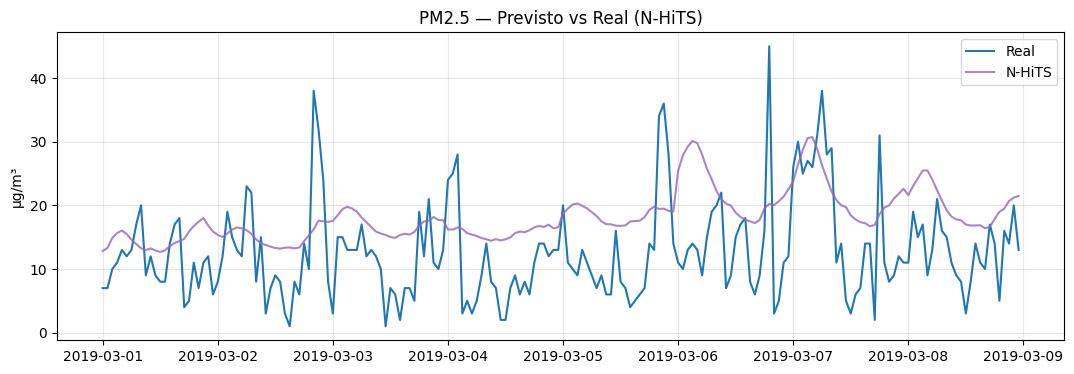

In [19]:
jan = slice("2019-03-01", "2019-03-08")
plt.figure(figsize=(13, 4))
plt.plot(as_[jan], label="Real", lw=1.5)
plt.plot(ps[jan], label="N-HiTS", lw=1.5, alpha=0.8, color="tab:purple")
plt.title("PM2.5 — Previsto vs Real (N-HiTS)"); plt.ylabel("µg/m³")
plt.legend(); plt.grid(alpha=0.3); plt.show()

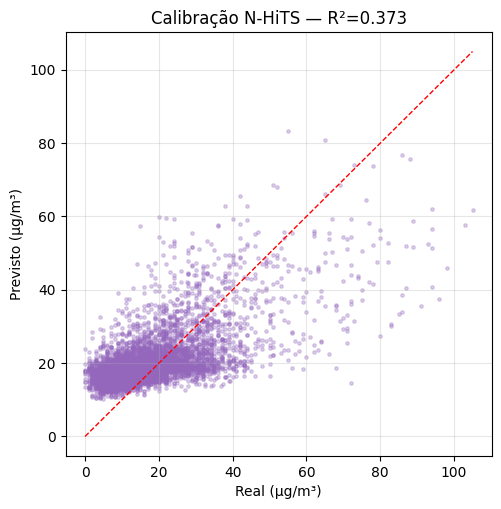

In [20]:
plt.figure(figsize=(5.5, 5.5))
plt.scatter(as_, ps, s=6, alpha=0.3, color="tab:purple")
lim = max(as_.max(), ps.max())
plt.plot([0, lim], [0, lim], "r--", lw=1)
plt.xlabel("Real (µg/m³)"); plt.ylabel("Previsto (µg/m³)")
plt.title(f"Calibração N-HiTS — R²={r2_score(actual_t, pred_t):.3f}")
plt.grid(alpha=0.3); plt.show()

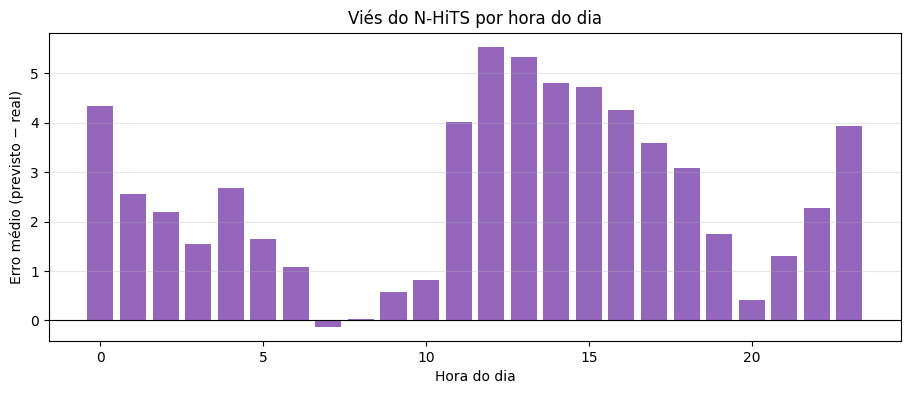

In [21]:
resid = (ps - as_)
por_hora = resid.groupby(resid.index.hour).mean()
plt.figure(figsize=(11, 4))
plt.bar(por_hora.index, por_hora.values, color="tab:purple")
plt.axhline(0, color="k", lw=0.8)
plt.xlabel("Hora do dia"); plt.ylabel("Erro médio (previsto − real)")
plt.title("Viés do N-HiTS por hora do dia"); plt.grid(alpha=0.3, axis="y"); plt.show()

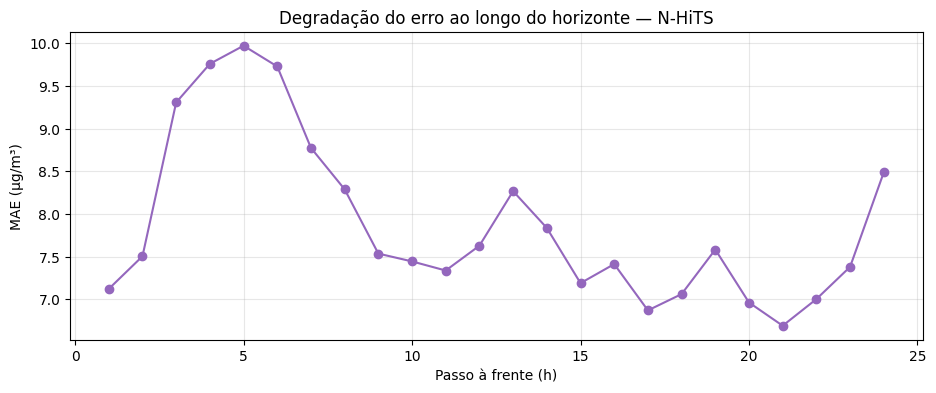

In [22]:
errs = []
for fc in hf_t:
    pr = scaler_y.inverse_transform(fc)
    ac = target.slice_intersect(pr)
    n = min(len(pr), len(ac))
    errs.append(np.abs(pr.values().flatten()[:n] - ac.values().flatten()[:n]))
mae_h = np.vstack([e for e in errs if len(e) == 24]).mean(axis=0)

plt.figure(figsize=(11, 4))
plt.plot(range(1, 25), mae_h, marker="o", color="tab:purple")
plt.xlabel("Passo à frente (h)"); plt.ylabel("MAE (µg/m³)")
plt.title("Degradação do erro ao longo do horizonte — N-HiTS")
plt.grid(alpha=0.3); plt.show()